In [1]:
import numpy as np
from pathlib import Path
from plyfile import PlyData, PlyElement
import matplotlib.pyplot as plt

from matplotlib import cm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics.classification import BinaryF1Score, BinaryPrecision, BinaryRecall, BinaryMatthewsCorrCoef, BinaryJaccardIndex, BinaryAccuracy

import torchsummary

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
# We start with loading the .ssm data in this cell to keep the data loaded in the following
def load_full_dataset(dataset='Train'):
    # 1) Path Definition
    # base directory for the chosen dataset
    base_path = Path('../data/Challenge-ABC') / dataset
    if not base_path.exists(): # verification
        print(f"Error: Dataset folder {base_path} not found, check 'dataset' argument.")
        return None
    ssm_dir = base_path / 'SSM_Challenge-ABC'
    lb_dir = base_path / 'lb'

    X_list = []
    y_list = []

    ssm_files = list(ssm_dir.glob('*.ssm'))
    total_files = len(ssm_files)

    for i, ssm_file in enumerate(ssm_files, 1):
        file_id = ssm_file.stem
        lb_file = lb_dir / f"{file_id}.lb"

        # check that the labels file exists
        if not lb_file.exists():
            print(f"Error: Didn't find labels file for {file_id}.ply -> ignored.")
            continue

        features = np.loadtxt(ssm_file, skiprows=5, dtype='float32').reshape(-1, 20, 16)
        labels = np.loadtxt(lb_file, dtype='int')

        if len(labels) == len(features):
            X_list.append(features)
            y_list.append(labels)
        else:
            print(f"Error: Dimension error for {file_id} -> ignored.")

        if i % 20 == 0:
            print(f"Loading : {i}/{total_files} files...")

    X = np.vstack(X_list)
    y = np.concatenate(y_list)    
    
    return X, y

print("Train dataset loading...")
X_train, y_train = load_full_dataset('Train')
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nValidation dataset loading...")
X_val, y_val = load_full_dataset('Validation')
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


Train dataset loading...
Loading : 20/198 files...
Loading : 40/198 files...
Loading : 60/198 files...
Loading : 80/198 files...
Loading : 100/198 files...
Loading : 120/198 files...
Loading : 140/198 files...
Loading : 160/198 files...
Loading : 180/198 files...
X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)

Validation dataset loading...
Loading : 20/50 files...
Loading : 40/50 files...
X_val shape: (690211, 20, 16)
y_val shape: (690211,)


In [4]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print(type(X_train))
print(type(y_train))
print(type(X_val))
print(type(y_val))

# Transform numpy's arrays to torch tensors:
X_train = torch.tensor(X_train).to(torch.float)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val).to(torch.float)
y_val = torch.tensor(y_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
torch.Size([3174768, 20, 16]) torch.Size([3174768])
torch.Size([690211, 20, 16]) torch.Size([690211])


In [5]:
class MLP(nn.Module):
    def __init__(self, num_hidden_1=64, num_hidden_2=64):
        super(MLP, self).__init__()
        self.layer_1 = torch.nn.Linear(320, num_hidden_1)
        self.layer_2 = torch.nn.Linear(num_hidden_1, num_hidden_2)
        self.layer_3 = torch.nn.Linear(num_hidden_2, 2)
        self.num_hidden_1 = num_hidden_1
        self.num_hidden_2 = num_hidden_2

    def forward(self, x):
        # Flatten the input from [batch_size, 20, 16] to [batch_size, 320]
        x = x.view(x.size(0), -1)

        # 1st layer
        out = self.layer_1(x)
        #out = torch.tanh(out) 
        out = torch.sigmoid(out)
        
        # 2nd layer
        out = self.layer_2(out)
        out = torch.sigmoid(out)

        # 3rd/output layer
        out = self.layer_3(out)
        return out

In [6]:
# Check paramters number
model = MLP().to(device)

print(torchsummary.summary(model,input_size=(320,)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]          20,544
            Linear-2                   [-1, 64]           4,160
            Linear-3                    [-1, 2]             130
Total params: 24,834
Trainable params: 24,834
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.09
Estimated Total Size (MB): 0.10
----------------------------------------------------------------
None


In [8]:
# Train Function
def train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=50, batch_size=1024, lr=0.01, device='cpu'):
    model = MLP().to(device)
    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)
    y_val_gpu = y_val.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    #optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # --- Metrics ---
    # Dictionnary to store the complete history
    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [], 
        'val_mcc': [], 'val_iou': []
    }

    f1_metric = BinaryF1Score().to(device)
    precision_metric = BinaryPrecision().to(device)
    recall_metric = BinaryRecall().to(device)
    mcc_metric = BinaryMatthewsCorrCoef().to(device)
    iou_metric = BinaryJaccardIndex().to(device)
    acc_metric = BinaryAccuracy().to(device)
    
    print("Start of training...")
    
    for epoch in range(1, nb_epochs + 1):

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        
        # Create random permutation of indexes to shuffle the dataset at each epoch withour copying the whole dataset 
        idx = torch.randperm(X_train_gpu.size(0), device=device)

        # Loop over the dataset but instead of copying and shuffling the whole dataset, we work on the indexes 
        # so we slice only the indexes and pick the data directly from the original tensor based on the shuffled indexes
        for i in range(0, X_train_gpu.size(0), batch_size):
            # extract only the indexes for the current batch
            batch_idx = idx[i : i + batch_size]

            # pick the batch data from the data tensor 
            inputs = X_train_gpu[batch_idx]
            labels = y_train_gpu[batch_idx]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)   
            
        epoch_train_loss = running_train_loss / X_train_gpu.size(0)
        history['train_loss'].append(epoch_train_loss)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0

        f1_metric.reset()
        precision_metric.reset()
        recall_metric.reset()
        mcc_metric.reset()
        iou_metric.reset()
        acc_metric.reset()

        with torch.no_grad():
            # same idea but without shuffling and no need to compute gradients
            for i in range(0, X_val_gpu.size(0), batch_size):
                inputs = X_val_gpu[i : i + batch_size]
                labels = y_val_gpu[i : i + batch_size]
      
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                f1_metric.update(predicted, labels)
                precision_metric.update(predicted, labels)
                recall_metric.update(predicted, labels)
                mcc_metric.update(predicted, labels)
                iou_metric.update(predicted, labels)
                acc_metric.update(predicted, labels)
                
        epoch_val_loss = running_val_loss / X_val_gpu.size(0)
        history['val_loss'].append(epoch_val_loss)
        
        
        # --- Compute Evaluation Metrics ---
        val_prec = precision_metric.compute().item()
        val_rec = recall_metric.compute().item()
        val_f1 = f1_metric.compute().item()
        val_mcc = mcc_metric.compute().item()
        val_iou =  iou_metric.compute().item()
        val_acc = acc_metric.compute().item() * 100.0
        
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        history['val_mcc'].append(val_mcc)
        history['val_iou'].append(val_iou)

        print(f"Epoch [{epoch}/{nb_epochs}] | T.Loss: {epoch_train_loss:.4f} | V.Loss: {epoch_val_loss:.4f} | F1: {val_f1:.4f} | MCC: {val_mcc:.4f}")

    # Free VRAM data 
    del X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu, f1_metric, precision_metric, recall_metric, mcc_metric, iou_metric
    torch.cuda.empty_cache()
    
    return history, model

In [15]:
print(f"Training on device: {device}")

metrics_history, model = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=100, batch_size=4096, device=device)

Training on device: cuda
Start of training...
Epoch [1/100] | T.Loss: 0.0235 | V.Loss: 0.0213 | F1: 0.9486 | MCC: 0.9456
Epoch [2/100] | T.Loss: 0.0088 | V.Loss: 0.0202 | F1: 0.9554 | MCC: 0.9529
Epoch [3/100] | T.Loss: 0.0083 | V.Loss: 0.0280 | F1: 0.9317 | MCC: 0.9285
Epoch [4/100] | T.Loss: 0.0072 | V.Loss: 0.0189 | F1: 0.9594 | MCC: 0.9571
Epoch [5/100] | T.Loss: 0.0065 | V.Loss: 0.0217 | F1: 0.9640 | MCC: 0.9620
Epoch [6/100] | T.Loss: 0.0054 | V.Loss: 0.0223 | F1: 0.9577 | MCC: 0.9552
Epoch [7/100] | T.Loss: 0.0056 | V.Loss: 0.0202 | F1: 0.9571 | MCC: 0.9548
Epoch [8/100] | T.Loss: 0.0051 | V.Loss: 0.0193 | F1: 0.9525 | MCC: 0.9501
Epoch [9/100] | T.Loss: 0.0061 | V.Loss: 0.0192 | F1: 0.9617 | MCC: 0.9596
Epoch [10/100] | T.Loss: 0.0046 | V.Loss: 0.0203 | F1: 0.9709 | MCC: 0.9692
Epoch [11/100] | T.Loss: 0.0041 | V.Loss: 0.0154 | F1: 0.9709 | MCC: 0.9692
Epoch [12/100] | T.Loss: 0.0038 | V.Loss: 0.0138 | F1: 0.9665 | MCC: 0.9647
Epoch [13/100] | T.Loss: 0.0042 | V.Loss: 0.0131 | 

In [16]:
print(f"F1-scores:\n {metrics_history['val_f1']}")
print(f"Precision:\n {metrics_history['val_precision']}")
print(f"Recall:\n {metrics_history['val_recall']}")
print(f"MCC:\n {metrics_history['val_mcc']}")
print(f"IoU:\n {metrics_history['val_iou']}")

F1-scores:
 [0.9485965967178345, 0.9554477334022522, 0.9316583275794983, 0.9593824744224548, 0.9640072584152222, 0.9576640725135803, 0.9570913910865784, 0.9525057077407837, 0.9617354273796082, 0.9709237217903137, 0.9709210395812988, 0.9664837718009949, 0.9701167941093445, 0.9700325131416321, 0.9716828465461731, 0.9665085077285767, 0.9724262952804565, 0.9657557010650635, 0.974966824054718, 0.9476386308670044, 0.9643788933753967, 0.9419147372245789, 0.9509203433990479, 0.97339928150177, 0.972542941570282, 0.9711515307426453, 0.9689224362373352, 0.9691627621650696, 0.9710649251937866, 0.9727113246917725, 0.9493603706359863, 0.972627580165863, 0.9730591773986816, 0.9716086983680725, 0.9573375582695007, 0.9613733887672424, 0.9606728553771973, 0.9620671272277832, 0.9665098786354065, 0.9703875780105591, 0.9754860997200012, 0.9756361246109009, 0.9748392701148987, 0.9748424291610718, 0.9688202738761902, 0.9489585161209106, 0.9709679484367371, 0.9536442756652832, 0.9604013562202454, 0.9732544422

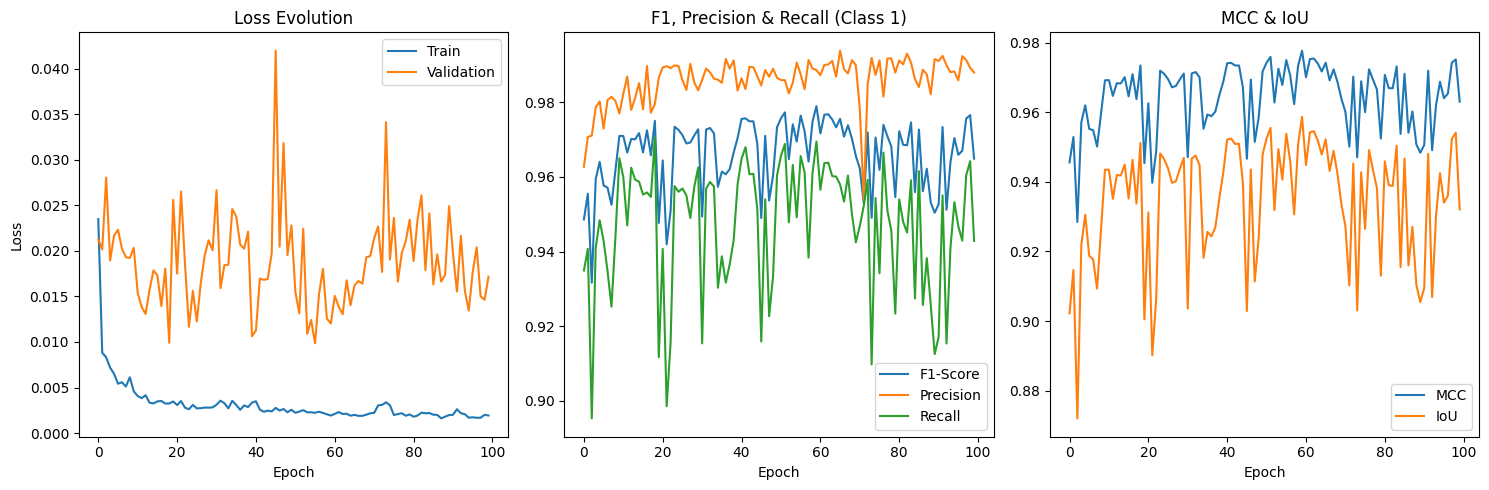

In [19]:
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 3, 1)
plt.title("Loss Evolution")
plt.plot(metrics_history['train_loss'], label="Train")
plt.plot(metrics_history['val_loss'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# F1-score, Precision, Recall
plt.subplot(1, 3, 2)
plt.title("F1, Precision & Recall (Class 1)")
plt.plot(metrics_history['val_f1'], label="F1-Score")
plt.plot(metrics_history['val_precision'], label="Precision")
plt.plot(metrics_history['val_recall'], label="Recall")
plt.xlabel("Epoch")
plt.legend()

# MCC and IoU
plt.subplot(1, 3, 3)
plt.title("MCC & IoU")
plt.plot(metrics_history['val_mcc'], label="MCC")
plt.plot(metrics_history['val_iou'], label="IoU")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()